## Introducción a PyTorch (Parte 2)

<a target="_blank" href="https://colab.research.google.com/github/pglez82/DeepLearningWeb/blob/master/labs/notebooks/Introducci%C3%B3n%20a%20PyTorch%20(Parte%202).ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

En esta segunda parte del tutorial vamos a empezar a usar los tensores como herramientas fundamentales para construir redes neuronales. Es decir, vamos a utilizar la capacidad de los tensores de calcular **gradientes**. La capacidad de construir grafos computacionales y calcular gradientes de manera automática es una de las características más importantes de frameworks como PyTorch. 



#### Tensores y gradientes
Por defecto, un tensor no tiene espacio para almacenar su gradiente:

In [3]:
import torch

t1 = torch.tensor([2.,3.])
print(t1)
print(t1.requires_grad)


tensor([2., 3.])
False


Si queremos ser capaces de hacer backpropagation y que el tensor pueda calcular su gradiente dentro de un grafo computacional, debemos indicarlo:

In [4]:
t1 = torch.tensor([2.,3.], requires_grad=True)
print(t1)
print(t1.requires_grad)

tensor([2., 3.], requires_grad=True)
True


Ten en cuenta que para que el tensor pueda usar **requires_grad**, su tipo debe de ser float o uno de sus subtipos.

Vamos a crear ahora un grafo computacional simple y a calcular los gradientes de manera sencilla. Por ejemplo, imaginemos las siguientes operaciones:

In [5]:
x = torch.arange(3, dtype=torch.float32, requires_grad=True)
z = x+1
z = z**2
z = z+2
y = z.mean()
print(y)


tensor(6.6667, grad_fn=<MeanBackward0>)


La función que estamos programando aquí es la siguiente $$y=\dfrac{\sum_{i=1}^n{(x_i+1)^2+2}}{n}$$

Podemos ahora calcular el gradiente de $y$ con respecto a $x_i$:

In [6]:
y.backward()
print(x.grad)

tensor([0.6667, 1.3333, 2.0000])


Es decir, lo que estamos visualizando aquí es el cálculo del gradiente, es decir, $\dfrac{\partial{y}}{\partial{x_i}}$ para cada una de las entradas $x_i$. Te dejo como ejercicio que hagas estos cáculos tu con papel y lápiz utilizando la **regla de la cadena** y te salga el mismo resultado.

#### Visualización del grafo computacional
Vamos ahora a visualizar el grafo computacional para el ejemplo anterior. Para ello debemos utilizar un paquete extra (torchviz, que no viene en PyTorch por defecto). En un notebook podríamos instalarlo con `!pip install nombre_librería`.

**Importante:**: Para que esta librería funcione es necesario instalar graphviz en el sistema. `sudo apt update && sudo apt install graphviz`.

In [7]:
%pip install torchviz

Note: you may need to restart the kernel to use updated packages.


Creamos ahora el grafo computacional:

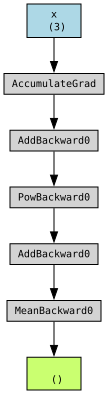

In [8]:
from torchviz import make_dot

dot = make_dot(y, params={"x": x})

dot

### Ejercicios propuestos

1) Prueba a realizar el cálculo analítico de la función anterior en papel y a calcular las derivadas parciales. ¿Obtienes el mismo resultado?

2) Comprueba los tipos de los tensores, ¿qué sucede si cambias la creación del tensor por `t1 = torch.tensor([2,3], requires_grad=True)`?. ¿Por qué? 

3) Implementa la siguiente función en PyTorch $$y=\dfrac{\sum_{i=1}^n{sin(x_i)×exp(x_i)+\dfrac{1}{x_i+2}}}{n}$$.
   - Dibuja su grafo computacional.
   - Crea un tensor con números desde 1 hasta 5.
   - Evalúa esta función para este tensor de entrada.
   - Calcula el gradiente correspondiente para cada una de estas entradas $\dfrac{\partial{y}}{\partial{x_i}}$.

4) Dado el siguiente dataset:

   | x  | y |
   | -------- | ------- |
   | 0  | 0 |
   | 1  | 2 |
   | 2  | 4 |
   | 3  | 6  |
   | 4    | 8 |
   | 5    | 10 |

Crea el código necesario para entrenar un perceptrón usando PyTorch.
 - Entréna tu perceptrón durante 1000 épocas con un learning rate de 0.01. 
 - Imprime el error (MSE) cada 100 épocas. 
 - Una vez entrenado el perceptrón, predice la y para un valor x=6.

In [ ]:

# EJERCICIO 2
# Da error (RuntimeError) porque requires_grad=True solo soporta tipos float/complejos,
# y al pasar enteros [2, 3] crea un tensor de tipo torch.int64.


# EJERCICIO 3


x = torch.arange(1.0, 6.0, requires_grad=True)
term = torch.sin(x) * torch.exp(x) + 1.0 / (x + 2.0)
y = term.mean()
print(y)

y.backward()
print(x.grad)


dot = make_dot(y, params={"x": x})[cite: 2]
dot 


# EJERCICIO 4




X = torch.tensor([[0.0], [1.0], [2.0], [3.0], [4.0], [5.0]])
Y = torch.tensor([[0.0], [2.0], [4.0], [6.0], [8.0], [10.0]])


criterion = nn.MSELoss()[cite: 2]
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)[cite: 2]

# Entrenamiento (1000 épocas, lr=0.01, print cada 100)[cite: 2]
for epoch in range(1, 1001):[cite: 2]
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, Y)
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:[cite: 2]
        print(f"Época {epoch} - Error (MSE): {loss.item():.6f}")[cite: 2]

# Predicción para x = 6[cite: 2]
x_test = torch.tensor([[6.0]])[cite: 2]
pred_6 = model(x_test)
print(f"Predicción para x=6: {pred_6.item():.4f}")[cite: 2]